In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

In [11]:
df = pd.read_csv("Admission_Predict_2022_2026_skewed.csv")
print(df.head())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR       CGPA  \
0           1        326          115                  4  4.5   4.5  8.713564   
1           2        296           98                  4  4.0   4.5  7.174594   
2           3        292           95                  3  3.0   3.5  6.798360   
3           4        295          101                  3  3.5   2.5  7.016065   
4           5        291           95                  2  2.0   3.0  6.832066   

   Research  Chance of Admit   Year  
0         1              0.92  2022  
1         1              0.76  2022  
2         1              0.72  2022  
3         1              0.80  2022  
4         0              0.65  2022  


In [12]:
# select the input feature
x = df[
    [
        "GRE Score",
        "TOEFL Score",
        "University Rating",
        "SOP",
        "LOR ",
        "CGPA",
        "Research",
        "Year"
    ]
]

print(x.head())

   GRE Score  TOEFL Score  University Rating  SOP  LOR       CGPA  Research  \
0        326          115                  4  4.5   4.5  8.713564         1   
1        296           98                  4  4.0   4.5  7.174594         1   
2        292           95                  3  3.0   3.5  6.798360         1   
3        295          101                  3  3.5   2.5  7.016065         1   
4        291           95                  2  2.0   3.0  6.832066         0   

   Year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


In [13]:
print("before transformation:")
print(x.skew())

before transformation:
GRE Score            2.022737
TOEFL Score          1.005994
University Rating    0.048623
SOP                 -0.257402
LOR                 -0.093620
CGPA                 2.006651
Research            -0.012018
Year                 0.000000
dtype: float64


In [14]:

# make values positive
x_box_input = x.copy()

for col in x_box_input.columns:
    if x_box_input[col].min() <= 0:
        x_box_input[col] = (
            x_box_input[col]
            - x_box_input[col].min()
            + 1
        )

In [15]:
# apply box-cox
box = PowerTransformer(method="box-cox")
x_box = box.fit_transform(x_box_input)
box_df = pd.DataFrame(
    x_box,
    columns=x.columns
)

print("\nbox-cox skewness:")
print(box_df.skew())


box-cox skewness:
GRE Score            0.000000
TOEFL Score          0.000000
University Rating   -0.138971
SOP                 -0.133991
LOR                 -0.060285
CGPA                 0.499384
Research            -0.012018
Year                -0.000215
dtype: float64


In [17]:
# Yeo-Johnson method in pow tranformataion 
yeo = PowerTransformer(method="yeo-johnson")
x_yeo = yeo.fit_transform(x)
yeo_df = pd.DataFrame(
    x_yeo,
    columns=x.columns
3)

print("\nYeo-Johnson skewness:")
print(yeo_df.skew())


Yeo-Johnson skewness:
GRE Score            0.000000
TOEFL Score          0.000000
University Rating   -0.092061
SOP                 -0.106483
LOR                 -0.046794
CGPA                 0.000000
Research            -0.012018
Year                -0.000214
dtype: float64


In [18]:
# compaire the both tech 
compare = pd.DataFrame({
    "Original": x.skew(),
    "Box-Cox": box_df.skew(),
    "Yeo-Johnson": yeo_df.skew()
})

print("\nSkewness Comparison:")
print(compare)


Skewness Comparison:
                   Original   Box-Cox  Yeo-Johnson
GRE Score          2.022737  0.000000     0.000000
TOEFL Score        1.005994  0.000000     0.000000
University Rating  0.048623 -0.138971    -0.092061
SOP               -0.257402 -0.133991    -0.106483
LOR               -0.093620 -0.060285    -0.046794
CGPA               2.006651  0.499384     0.000000
Research          -0.012018 -0.012018    -0.012018
Year               0.000000 -0.000215    -0.000214


<Axes: >

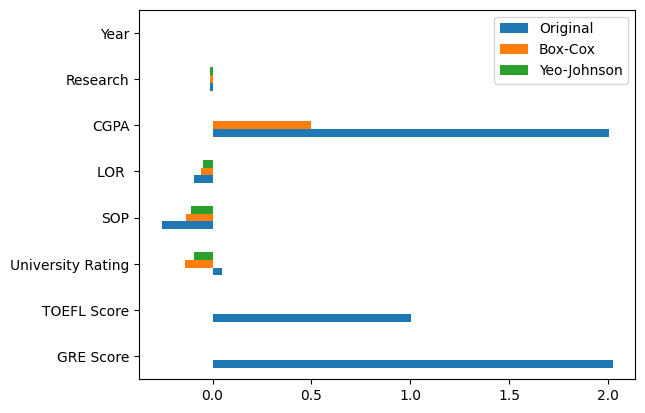

In [22]:
compare.plot(kind='barh')